<a href="https://colab.research.google.com/github/taniagoa/Tercer-challenge-CD-Telecom-X-parte2/blob/main/telecomXparte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
datos=pd.read_csv('/content/datos_tratados.csv')
datos.head()

,IDcliente,evasion,genero,adultoMayor,pareja,dependientes,permanencia,telefonoFijo,MultipleLines,internet,...,DeviceProtection,servicioTecnico,StreamingTV,StreamingMovies,contrato,reciboElectronico,metodoDePago,cargoMensual,cargoTotal,cuentasDiarias
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,5.466667
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,4.991667
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,6.158333
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,8.166667
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,6.991667


In [20]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   IDcliente          7032 non-null   object 
 1   evasion            7032 non-null   int64  
 2   genero             7032 non-null   object 
 3   adultoMayor        7032 non-null   int64  
 4   pareja             7032 non-null   object 
 5   dependientes       7032 non-null   object 
 6   permanencia        7032 non-null   int64  
 7   telefonoFijo       7032 non-null   object 
 8   MultipleLines      7032 non-null   object 
 9   internet           7032 non-null   object 
 10  OnlineSecurity     7032 non-null   object 
 11  OnlineBackup       7032 non-null   object 
 12  DeviceProtection   7032 non-null   object 
 13  servicioTecnico    7032 non-null   object 
 14  StreamingTV        7032 non-null   object 
 15  StreamingMovies    7032 non-null   object 
 16  contrato           7032 

Teniendo en cuenta los graficos de histograma de la primera parte de telecomX podemos identificar las columnas que no tienen relevancia para evaluar la evasion de clientes, estas columnas seran eliminadas para evitar que afecten al modelo

In [21]:
datos2=datos.drop(columns=['IDcliente','adultoMayor','pareja','dependientes'])
datos2.head()

,evasion,genero,permanencia,telefonoFijo,MultipleLines,internet,OnlineSecurity,OnlineBackup,DeviceProtection,servicioTecnico,StreamingTV,StreamingMovies,contrato,reciboElectronico,metodoDePago,cargoMensual,cargoTotal,cuentasDiarias
0,0,Female,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,5.466667
1,0,Male,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,4.991667
2,1,Male,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,6.158333
3,1,Male,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,8.166667
4,1,Female,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,6.991667


Para los servicios agregados encontramos que la opcion 'No internet service' es redundante con la opcion 'No', asi que aplicamos un reeemplazo.
Para hacer mas sencillo es analisis cambiamos las opciones 'Yes' y 'No' por valores binarios 0 y 1

In [22]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'servicioTecnico', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    datos2[col] = datos2[col].replace({'No internet service': 'No'})

In [23]:
col_codificar=[
     'telefonoFijo','OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'servicioTecnico', 'StreamingTV', 'StreamingMovies'
    ]
for col in col_codificar:
  datos2[col]=datos2[col].replace({'No':0,'Yes':1})

/tmp/ipykernel_1202/3326107279.py:6: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Realizamos la codificacion de variables categoricas que tienen mas de una opcion usando OneHotEncoder

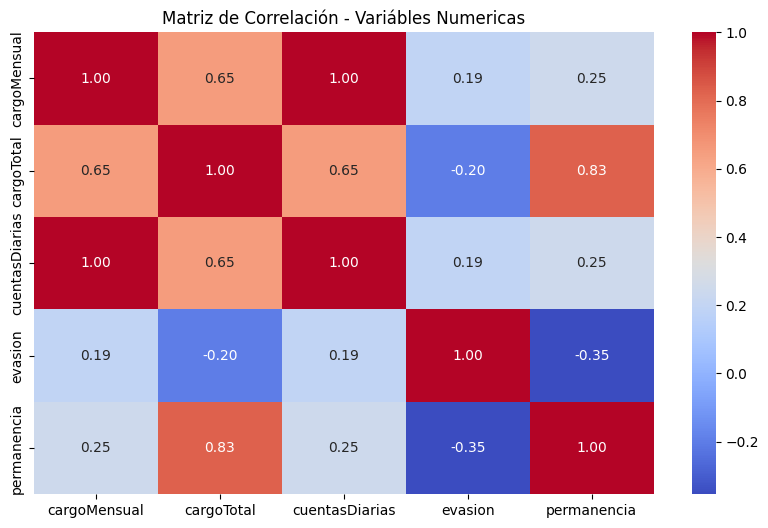

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
df_numeric = datos2.select_dtypes(include="float64")
df_numeric = df_numeric.copy()
df_numeric['evasion'] = datos2['evasion']
df_numeric['permanencia']=datos['permanencia']
corr_matrix = df_numeric.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

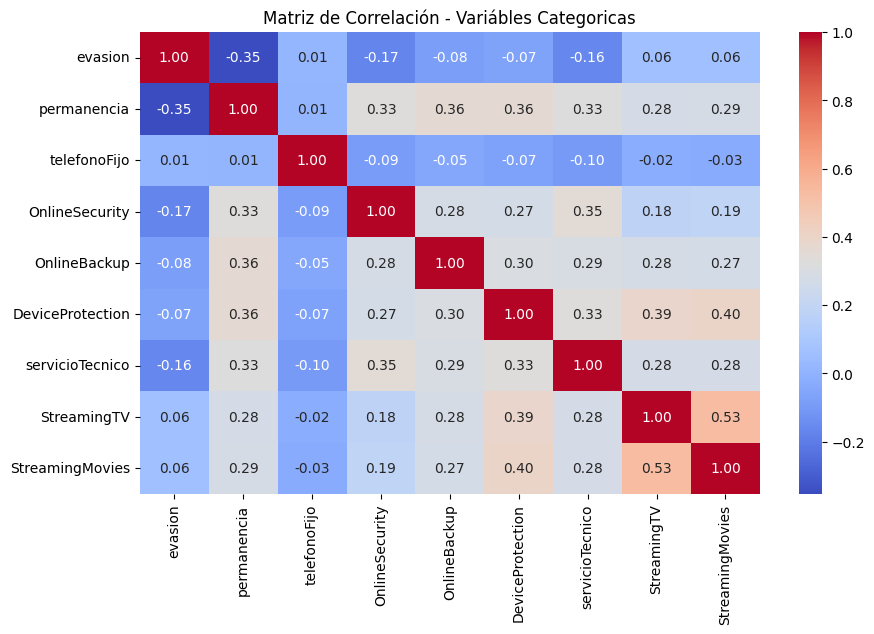

In [25]:
df_numeric = datos2.select_dtypes(include="int64")
corr_matrix = df_numeric.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Categoricas")
plt.show()

Se observa una correlacion debil entre la evasion y las variables numericas, en especial con 'cuentasDiarias' y 'cargoMensual', sin embargo se observa correlacion fuerte entre 'cargoTotal' y 'permanencia', 'cargoTotal' y'cuentasDiarias', 'cargoTotal' y 'cargoMensual', 'cargoMensual' y 'cuentasDiarias' para evitar esa correlacion eliminamos la columna 'cargoTotal' y 'cuentasDiarias'.
La variable que tiene correlacion mas debil con la evasion es 'telefonoFijo', se observa mucha correlacion entre 'StreamingTV' y 'StreamingMovies', eliminamos 'telefonofijo' y 'StreamingMovies'

In [26]:
datos2=datos2.drop(columns=['cargoTotal','cuentasDiarias','telefonoFijo','StreamingMovies'])
datos2.head()

,evasion,genero,permanencia,MultipleLines,internet,OnlineSecurity,OnlineBackup,DeviceProtection,servicioTecnico,StreamingTV,contrato,reciboElectronico,metodoDePago,cargoMensual
0,0,Female,9,No,DSL,0,1,0,1,1,One year,Yes,Mailed check,65.6
1,0,Male,9,Yes,DSL,0,0,0,0,0,Month-to-month,No,Mailed check,59.9
2,1,Male,4,No,Fiber optic,0,0,1,0,0,Month-to-month,Yes,Electronic check,73.9
3,1,Male,13,No,Fiber optic,0,1,1,0,1,Month-to-month,Yes,Electronic check,98.0
4,1,Female,3,No,Fiber optic,0,0,0,1,1,Month-to-month,Yes,Mailed check,83.9


In [27]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
X=datos2.drop('evasion',axis=1)
y=datos2['evasion']
columnas=X.columns
one_hot=make_column_transformer((OneHotEncoder(drop='if_binary'),['genero','internet','contrato','MultipleLines','metodoDePago']),remainder='passthrough',sparse_threshold=0,force_int_remainder_cols=False)
X=one_hot.fit_transform(X)
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__genero_Male', 'onehotencoder__internet_DSL',
       'onehotencoder__internet_Fiber optic',
       'onehotencoder__internet_No',
       'onehotencoder__contrato_Month-to-month',
       'onehotencoder__contrato_One year',
       'onehotencoder__contrato_Two year',
       'onehotencoder__MultipleLines_No',
       'onehotencoder__MultipleLines_No phone service',
       'onehotencoder__MultipleLines_Yes',
       'onehotencoder__metodoDePago_Bank transfer (automatic)',
       'onehotencoder__metodoDePago_Credit card (automatic)',
       'onehotencoder__metodoDePago_Electronic check',
       'onehotencoder__metodoDePago_Mailed check',
       'remainder__permanencia', 'remainder__OnlineSecurity',
       'remainder__OnlineBackup', 'remainder__DeviceProtection',
       'remainder__servicioTecnico', 'remainder__StreamingTV',
       'remainder__reciboElectronico', 'remainder__cargoMensual'],
      dtype=object)

In [28]:
X=pd.DataFrame(X,columns=one_hot.get_feature_names_out(columnas))

In [29]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
y=label_encoder.fit_transform(y)